<a href="https://colab.research.google.com/github/25040992-hann/Probabilidad-/blob/main/Unidad6/practica%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Proyecto Final: Análisis Estadístico de Datos COVID-19
Materia: Probabilidad y Estadística  
Grupo: 2YY
Periodo: 2 semestre  
Fecha de entrega: 28-05-26

Integrantes: Tiffany Hannay Guuerrero, Bryan Arellano Perdue

Docente: Jose Gabriel Rodriguez Rivas

In [1]:
from google.colab import drive
drive.mount('/content/drive')

#Carga el archivo directo desde Drive
import pandas as pd
covid = pd.read_csv('/content/drive/My Drive/covid2020-2021-codificado.csv', low_memory=False)

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

In [4]:
#Lee el archivo y sus datos para mostrar las primeras filas y verificar su estructura
covid = pd.read_csv('/content/drive/My Drive/covid2020-2021-codificado.csv', low_memory=False)
covid.head()

,SECTOR,SEXO,ENTIDAD_NAC,TIPO_PACIENTE,FECHA_INGRESO,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,EMBARAZO,...,DIABETES,EPOC,ASMA,HIPERTENSION,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,RESULTADO_ANTIGENO,UCI
0,Issste,Femenino,San Luis Potosí,Ambulatorio,2020-12-06,9999-99-99,No aplica,No,55,No,...,Si,No,No,No,No,No,No,No,Pendiente,No aplica
1,Issste,Masculino,San Luis Potosí,Ambulatorio,2020-02-20,9999-99-99,No aplica,No,59,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
2,Ssa,Femenino,Jalisco,Ambulatorio,2020-04-22,9999-99-99,No aplica,No,42,No,...,No,No,Si,No,No,No,No,No,Pendiente,No aplica
3,Ssa,Masculino,Chihuahua,Ambulatorio,2020-07-28,9999-99-99,No aplica,No,35,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
4,Ssa,Masculino,Ciudad De México,Ambulatorio,2020-08-18,9999-99-99,No aplica,No,51,No aplica,...,No,No,No,Si,No,No,No,No,Pendiente,No aplica


In [5]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12634194 entries, 0 to 12634193
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   SECTOR              object
 1   SEXO                object
 2   ENTIDAD_NAC         object
 3   TIPO_PACIENTE       object
 4   FECHA_INGRESO       object
 5   FECHA_DEF           object
 6   INTUBADO            object
 7   NEUMONIA            object
 8   EDAD                int64 
 9   EMBARAZO            object
 10  INDIGENA            object
 11  DIABETES            object
 12  EPOC                object
 13  ASMA                object
 14  HIPERTENSION        object
 15  CARDIOVASCULAR      object
 16  OBESIDAD            object
 17  RENAL_CRONICA       object
 18  TABAQUISMO          object
 19  RESULTADO_ANTIGENO  object
 20  UCI                 object
dtypes: int64(1), object(20)
memory usage: 2.0+ GB


In [6]:
#Filtra a los pacientes según su resultado de la prueba y devuleve el numero de personas que se econtaron en cada uno de los casos
#(positivo, negativo o pendientes)

res_posi = covid[covid['RESULTADO_ANTIGENO'] == 'Positivo'].shape[0]
print("La cantidad de resultados positivos es de: ", res_posi)

res_neg = covid[covid['RESULTADO_ANTIGENO'] == 'Negativo'].shape[0]
print("La cantidad de resultados negativos es de: ", res_neg)

res_pend = covid[covid['RESULTADO_ANTIGENO'] == 'Pendiente'].shape[0]
print("La cantidad de resultados pendientes es de: ", res_pend)

La cantidad de resultados positivos es de:  1774708
La cantidad de resultados negativos es de:  5853547
La cantidad de resultados pendientes es de:  5005939


In [7]:
#Clasifica el numero de personas segun la categoria que corresponden, ya sea, hospitalizados, ambulatorios, embarazadas o indigenas.

hospi = covid[covid['TIPO_PACIENTE'] == 'Hospitalizado'].shape[0]
print("La cantidad de pacientes hospitalizados es de: ", hospi)

ambulat = covid[covid['TIPO_PACIENTE'] == 'Ambulatorio'].shape[0]
print("La cantidad de pacientes ambulatorios es de: ", ambulat)

embarazada = covid[covid['EMBARAZO'] == 'Si'].shape[0]
print("La cantidad de mujeres embarazadas es de: ", embarazada)

indi = covid[covid['INDIGENA'] == 'Si'].shape[0]
print("La cantidad de pacientes indigenas es de: ", indi)

La cantidad de pacientes hospitalizados es de:  1090891
La cantidad de pacientes ambulatorios es de:  11543303
La cantidad de mujeres embarazadas es de:  122583
La cantidad de pacientes indigenas es de:  35240


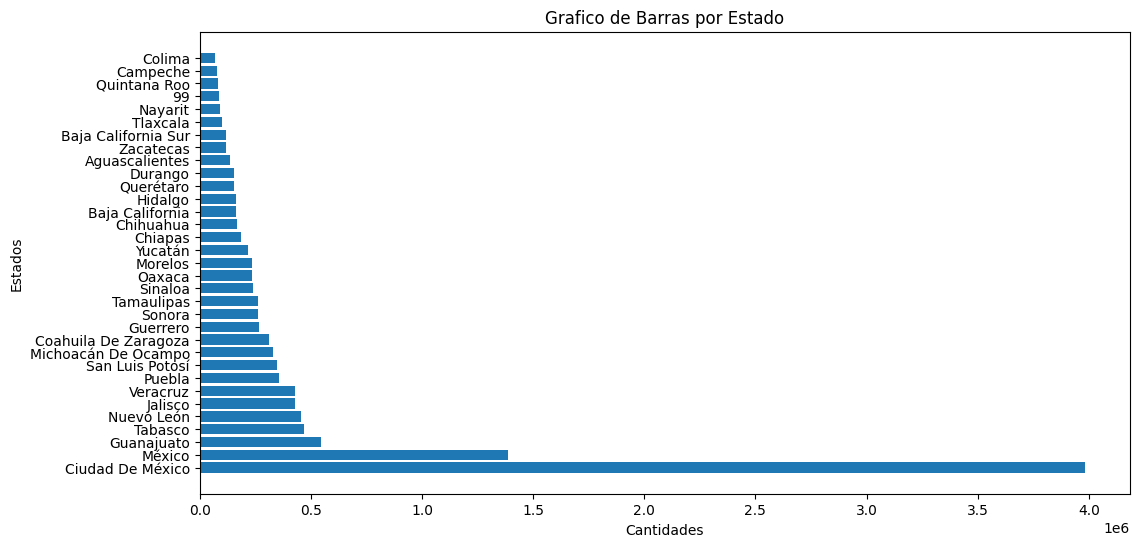

In [8]:
#Cuenta los pacientes que existen por esatdos y los grafica de forma horizontal, estando hasta arriba el estado con menos cantidad de pacientes y
#va hacia abajo conforme disminuye.

Estados = covid['ENTIDAD_NAC'].value_counts()

plt.figure(figsize=(12, 6))
plt.barh(Estados.index, Estados.values)
plt.ylabel('Estados')
plt.xlabel('Cantidades')
plt.title('Grafico de Barras por Estado')
plt.yticks(rotation=0)
plt.show()

Text(0, 0.5, 'Frecuencia')

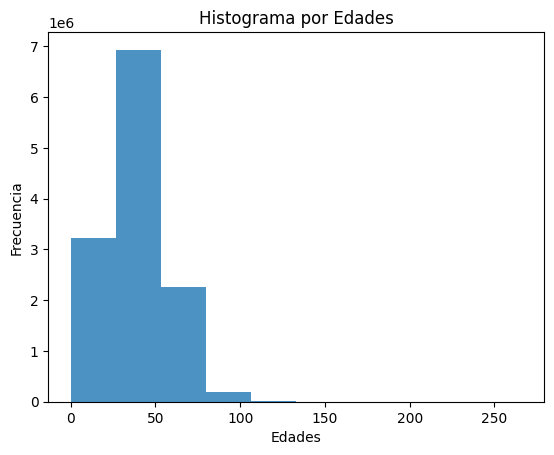

In [9]:
#Clasifica a los pacientes segun el rango de edades al que corresponden.

plt.hist(covid['EDAD'], alpha = 0.8)
plt.title('Histograma por Edades')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')

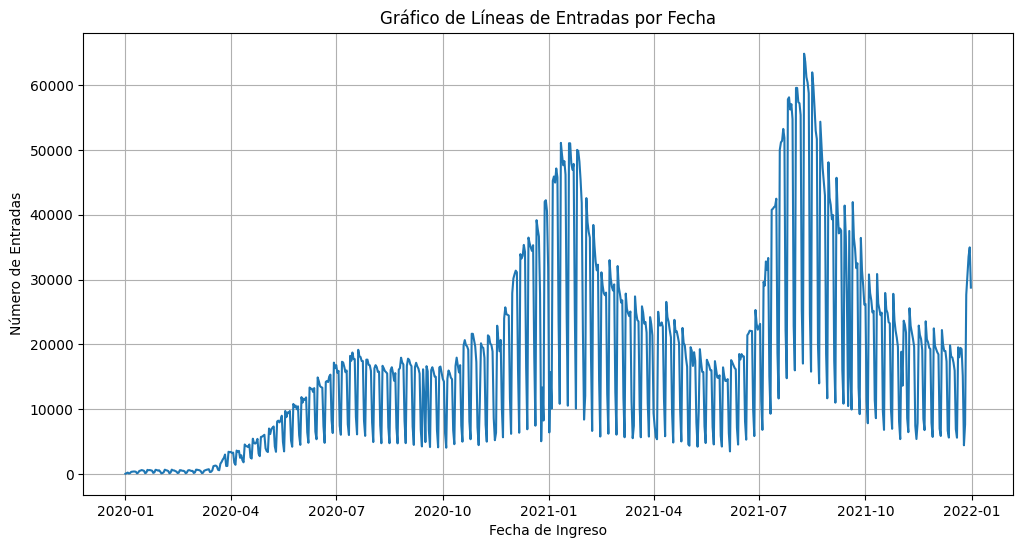

In [10]:
#Convierte la columna FECHA_INGRESO a formato de fecha real (datetime), esto permite ordenar y graficar cronológicamente.
#value_counts() cuenta cuántos pacientes ingresaron en cada fecha, mientras que sort_index() ordena las fechas en orden cronológico (antigua a más reciente).

covid['FECHA_INGRESO'] = pd.to_datetime(covid['FECHA_INGRESO'])
ingreso = covid['FECHA_INGRESO'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(ingreso.index, ingreso.values)
plt.title('Gráfico de Líneas de Entradas por Fecha')
plt.xlabel('Fecha de Ingreso')
plt.ylabel('Número de Entradas')
plt.grid(True)
plt.show()

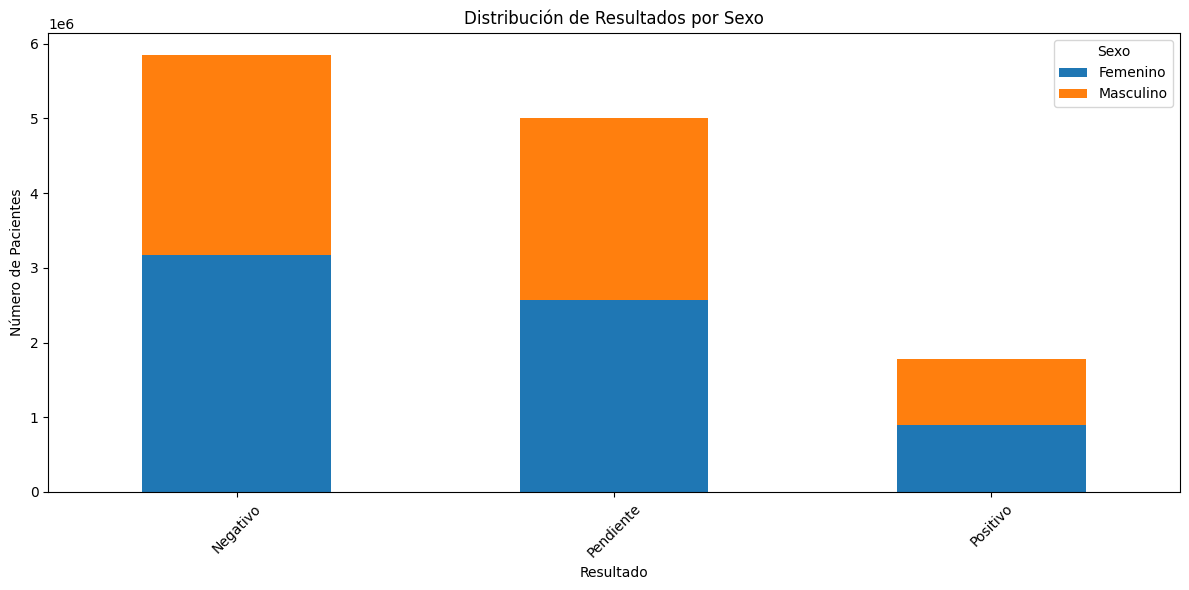

In [11]:
#groupby() ayuda a agrupa los datos por resultado de prueba (Positivo, Negativo, Pendiente) y por sexo (Hombre, Mujer).
#.size(), cuenta cuántos registros hay en cada combinación.
#.unstack(fill_value=0), ayuda a reorganizar la tabla para que cada resultado tenga columnas separadas por sexo.

sexo_resul = covid.groupby(['RESULTADO_ANTIGENO', 'SEXO']).size().unstack(fill_value=0)

sexo_resul.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribución de Resultados por Sexo')
plt.xlabel('Resultado')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

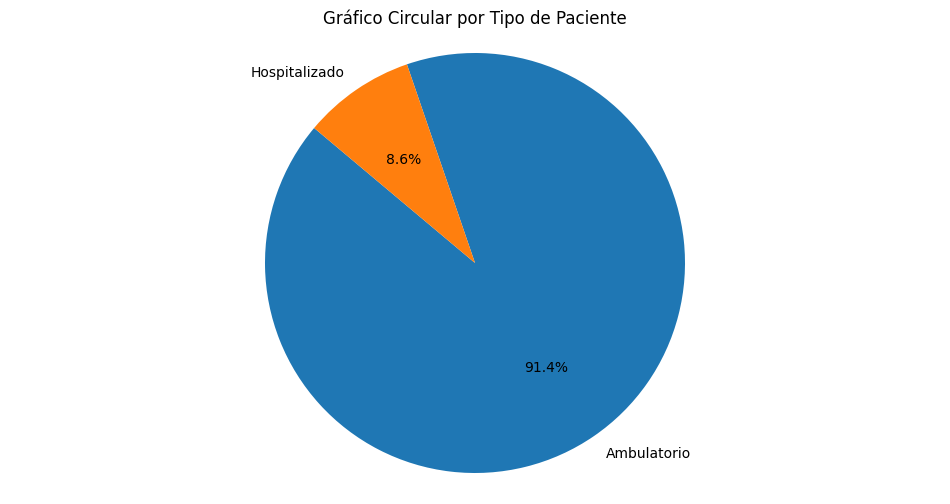

In [12]:
#value_counts(), ayuda a contar cuántos pacientes son hospitalizados y cuántos ambulatorios.
#plt.pie() hace el dibujo de un círculo dividido en secciones.
#labels=paciente.index, pone las etiquetas en el grafico (Hospitalizado, Ambulatorio), mientras que "autopct='%1.1f%%'" muestra el porcentaje en cada sección.

paciente = covid['TIPO_PACIENTE'].value_counts()

plt.figure(figsize=(12, 6))
plt.pie(paciente, labels=paciente.index, autopct='%1.1f%%', startangle=140)
plt.title('Gráfico Circular por Tipo de Paciente')
plt.axis('equal')
plt.show()

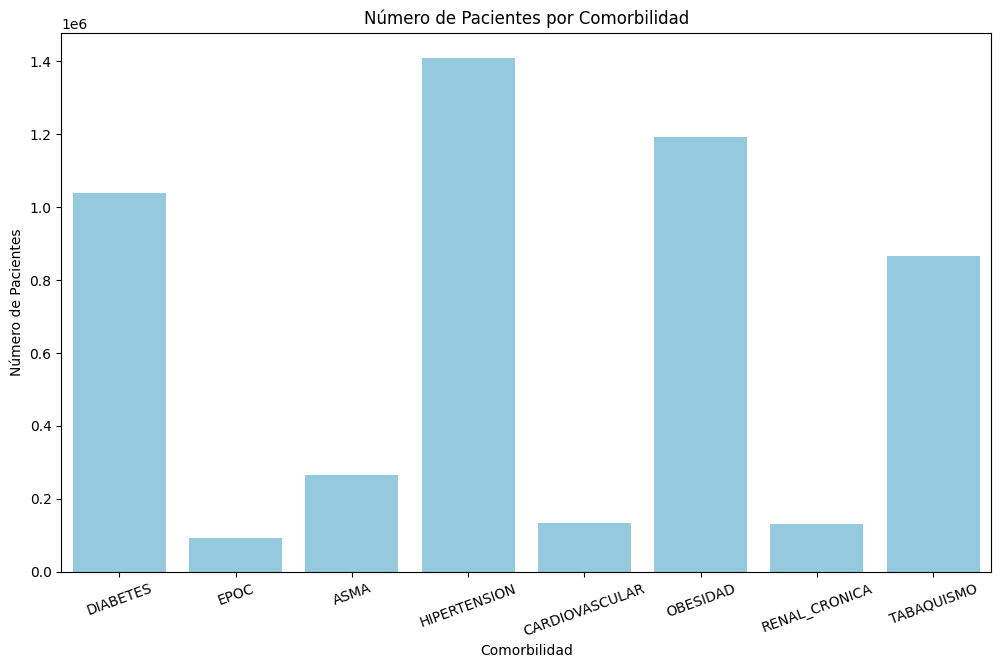

In [13]:
#Se define una lista con las enfermedades, para cada enfermedad, se cuenta cuántos pacientes tienen "Si" en esa columna.
#Se usa Seaborn para graficar, esto permite comparar visualmente qué comorbilidad es más común dentro de los pacientes.

comorbilidades = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']

comorbilidad_counts = {comorbilidad: (covid[comorbilidad] == 'Si').sum() for comorbilidad in comorbilidades}

comorbilidad_df = pd.DataFrame(list(comorbilidad_counts.items()), columns=['Comorbilidad', 'Número de Pacientes'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Comorbilidad', y='Número de Pacientes', data=comorbilidad_df, color='skyblue')
plt.title('Número de Pacientes por Comorbilidad')
plt.xlabel('Comorbilidad')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=20)
plt.show()

In [14]:
#total_registros, reperesenta al número total de pacientes en la base, para cada enfermedad, cuenta cuántos pacientes tienen un "Si".
#Divide ese número entre el total de pacientes y da como resultado la pobabilidad de cada una de las enfermedades.

comorbilidades = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']
total_registros = len(covid)

print('Análisis de Probabilidad Simple de Comorbilidades:')

for comorbilidad in comorbilidades:
    casos_si = covid[covid[comorbilidad] == 'Si'].shape[0]

    probabilidad = casos_si / total_registros

    print(f'  Probabilidad de {comorbilidad}: {probabilidad:.4f}')

Análisis de Probabilidad Simple de Comorbilidades:
  Probabilidad de DIABETES: 0.0822
  Probabilidad de EPOC: 0.0073
  Probabilidad de ASMA: 0.0209
  Probabilidad de HIPERTENSION: 0.1114
  Probabilidad de CARDIOVASCULAR: 0.0106
  Probabilidad de OBESIDAD: 0.0944
  Probabilidad de RENAL_CRONICA: 0.0103
  Probabilidad de TABAQUISMO: 0.0685


In [15]:
#Filtra los pacientes de un estado específico.
#Cuenta cuántos de esos pacientes tienen la comorbilidad.
#Divide entre el total de pacientes de ese estado.

comorbilidades = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']
entidades = covid['ENTIDAD_NAC'].unique()

prob_condicional = {}

for entidad in entidades:
    df_entidad = covid[covid['ENTIDAD_NAC'] == entidad]
    total_pacientes_entidad = len(df_entidad)

    if total_pacientes_entidad == 0:
        continue

    prob_condicional[entidad] = {}
    for comorbilidad in comorbilidades:
        pacientes_con_comorbilidad = df_entidad[df_entidad[comorbilidad] == 'Si'].shape[0]

        prob = pacientes_con_comorbilidad / total_pacientes_entidad
        prob_condicional[entidad][comorbilidad] = prob

prob_df = pd.DataFrame(prob_condicional).T
prob_df = prob_df.fillna(0)

print("Probabilidad Condicional de Comorbilidad por Entidad:")
print(prob_df.round(4))

Probabilidad Condicional de Comorbilidad por Entidad:
                      DIABETES    EPOC    ASMA  HIPERTENSION  CARDIOVASCULAR  \
San Luis Potosí         0.0968  0.0103  0.0209        0.1291          0.0121   
Jalisco                 0.1082  0.0171  0.0364        0.1558          0.0185   
Chihuahua               0.1056  0.0120  0.0320        0.1645          0.0187   
Ciudad De México        0.0651  0.0047  0.0187        0.0869          0.0083   
Aguascalientes          0.0757  0.0089  0.0252        0.1167          0.0123   
Chiapas                 0.0824  0.0066  0.0211        0.1086          0.0100   
Durango                 0.0912  0.0115  0.0227        0.1327          0.0127   
Nuevo León              0.0918  0.0049  0.0214        0.1130          0.0113   
México                  0.0668  0.0062  0.0143        0.0836          0.0085   
Yucatán                 0.0739  0.0063  0.0276        0.1129          0.0097   
Tamaulipas              0.1104  0.0080  0.0270        0.1492      

In [16]:
#media = 2360, es el promedio de casos por estado, la desviacion_estandar = 714, refleja cuánto varían los casos entre estados.
#"cdf" calcula la probabilidad acumulada hasta cierto valor.
#Restando cdf(3000) - cdf(2000) obtienes la probabilidad de que un estado tenga entre 2000 y 3000 casos positivos.

media = 2360
desviacion_estandar = 714

x1 = 2000
x2 = 3000

prob_hasta_x2 = norm.cdf(x2, loc=media, scale=desviacion_estandar)

prob_hasta_x1 = norm.cdf(x1, loc=media, scale=desviacion_estandar)

probabilidad_rango = prob_hasta_x2 - prob_hasta_x1

print(f"La probabilidad de que un estado tenga entre {x1} y {x2} casos positivos es: {probabilidad_rango:.4f}")

La probabilidad de que un estado tenga entre 2000 y 3000 casos positivos es: 0.5079


###Conclusiones
#####Gracias a los gráficos se puede ver que los casos de COVID se concentran principalmente en los pacientes calisificados en edades como adultos y adultos mayores.

#####La evolución de la enfermedad muestra picos claros de contagios y las comorbilidades como diabetes e hipertensión son las que se logran apreciar con mas frecuencia en los pacientes graves según las graficas hechas.

#####La gráfica de estados muestra cómo se distribuyen los casos de COVID en cada entidad, se observa que algunos estados concentran un número mucho mayor a otros. Esto significa que la pandemia no afectó de manera uniforme, si no que en los estados más poblados o con mayor movilidad se ven reflejados mayor cantidad de casos.

#####En general, los datos confirman que la pandemia tuvo un impacto desigual según el estado, la edad y las diferentes condiciones de salud de los pacientes. Tambien se puede concluir que las enfermedades aumentan el riesgo de complicaciones.

###Conclusión Personal (Bryan Arellano Perdue)
#####Durante la materia de Probabilidad y Estadística aprendí que los datos y la información pueden analizarse de muchas formas para obtener resultados útiles y tomar mejores decisiones. A lo largo de las diferentes unidades y prácticas se fueron viendo temas que ayudaron a entender cómo organizar datos, interpretarlos y representarlos mediante tablas, gráficas y diferentes cálculos estadísticos.

#####En las primeras prácticas se trabajó con medidas como la media, mediana, moda y desviación estándar, lo cual ayudó a comprender mejor el comportamiento de un conjunto de datos. Después, con los temas de probabilidad, se aprendió a calcular la posibilidad de que ocurrieran ciertos eventos y a entender cómo funcionan los experimentos aleatorios en situaciones reales.

#####Conforme avanzó la materia, se aprendió sobre distribuciones, muestreo e inferencia estadística, temas que ayudan a obtener conclusiones a partir de información limitada. También se realizaron diferentes ejercicios y análisis que permitieron aplicar la teoría de forma práctica y comprender mejor los resultados obtenidos.

#####Finalmente, en las últimas prácticas de correlación y regresión lineal, se entendió cómo se relacionan dos variables y cómo se pueden hacer predicciones usando modelos matemáticos sencillos. En general, considero que la materia fue útil porque no solo se aprendieron fórmulas, sino también cómo interpretar información y analizar datos de manera más clara y organizada para resolver problemas reales.

###Conclusión Personal (Tiffany Hannay Guerrero)
#####A lo largo de la asignatura aprendí a manejar los conceptos básicos y aplicados de la estadística: desde la estadística descriptiva para organizar y resumir datos, hasta los fundamentos de la probabilidad y las variables aleatorias. También trabajé con distribuciones de probabilidad, lo que me permitió modelar diferentes situaciones reales, y con regresión y correlación, que fueron útiles para identificar relaciones entre variables. Finalmente, la estadística aplicada me mostró cómo todo este conocimiento se conecta con problemas prácticos de la vida real.

#####La experiencia de usar Python fue muy útil porque me permitió llevar la teoría de los codigos a la práctica. Con las librerías pude hacer cálculos de manera rápida, generar gráficos claros y aplicar modelos estadísticos sin depender solo de procedimientos manuales. Esto me ayudó a visualizar mejor los datos, interpretar tendencias y comprobar resultados con mayor precisión.

#####En conclusión, la combinación de teoría y práctica me dejó claro que la estadística es una herramienta útil para analizar información, descubrir patrones y tomar decisiones fundamentadas, y que Python puede ayudarme para aplicar estos conocimientos de manera eficiente y mas rápida.